**Implementation of  RNN,GRU and LSTM Model for Time Series data**


Objective: To explore how a Stacked LSTM learns patterns from historical stock price data and predicts future closing prices.


In [9]:
# Importing necessary libraries
!pip install yfinance
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN, LSTM, GRU, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})
sns.set_palette('husl')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Add

In [10]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [11]:
EXCEL_FILE     = 'AAPL_stock_data.xlsx'   # Path to the local Excel file

df= pd.read_excel(EXCEL_FILE, header=[0, 1], index_col=0)
# --- Load from Excel ---
# The Excel file was originally saved by yfinance, which writes a multi-level
# column header (Price / Ticker / Date).  We read it with header=[0,1] and
# index_col=0, then flatten to a standard single-level DataFrame.
print(f"Loading data from '{EXCEL_FILE}' ...")

data = df[['Close']]
data.head(10)

Loading data from 'AAPL_stock_data.xlsx' ...


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.214893
2015-01-05,23.532726
2015-01-06,23.534937
2015-01-07,23.864952
2015-01-08,24.781897
2015-01-09,24.808474
2015-01-12,24.197168
2015-01-13,24.412016


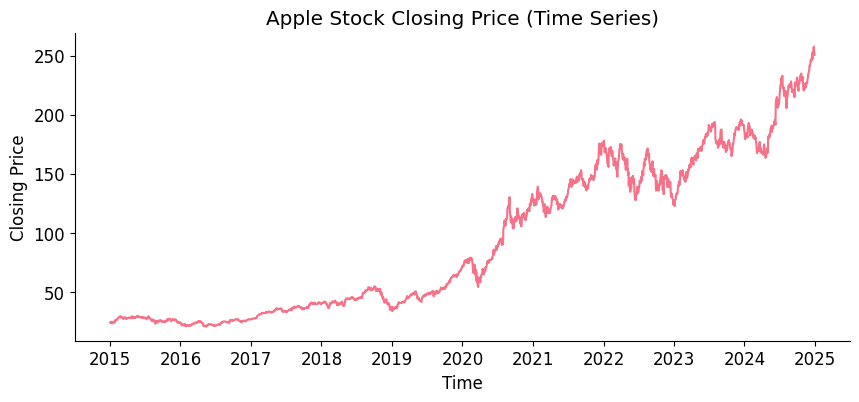

In [12]:
# Plot time series
plt.figure(figsize=(10, 4))
plt.plot(df['Close'])
plt.title("Apple Stock Closing Price (Time Series)")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.show()

In [13]:
# Preprocessing
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

window_size = 30

X, y = [], []
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(X.shape)
print(y.shape)
print(X_train.shape)
print(X_test.shape)# Preprocessing

(2485, 30, 1)
(2485, 1)
(1988, 30, 1)
(497, 30, 1)


In [14]:
# Inspect one trainingsample
X[0]

array([[0.01531498],
       [0.01243698],
       [0.0124463 ],
       [0.01383861],
       [0.01770712],
       [0.01781924],
       [0.0152402 ],
       [0.01614662],
       [0.01575413],
       [0.01296956],
       [0.01219401],
       [0.01474497],
       [0.01552055],
       [0.01818365],
       [0.0187256 ],
       [0.01883775],
       [0.01513745],
       [0.0209028 ],
       [0.0242574 ],
       [0.02263149],
       [0.02400515],
       [0.0240238 ],
       [0.02487413],
       [0.02567154],
       [0.02472404],
       [0.02546515],
       [0.0276228 ],
       [0.03030577],
       [0.031788  ],
       [0.03236964]])

In [15]:
X[30]

array([[0.03307324],
       [0.03390815],
       [0.03365486],
       [0.03463989],
       [0.03792325],
       [0.03714463],
       [0.0339738 ],
       [0.03550292],
       [0.03366423],
       [0.03425524],
       [0.03450852],
       [0.03373928],
       [0.03174113],
       [0.03191936],
       [0.03242594],
       [0.02995869],
       [0.02782917],
       [0.02990242],
       [0.02909562],
       [0.03037147],
       [0.03233212],
       [0.03367359],
       [0.03276366],
       [0.03126266],
       [0.0324916 ],
       [0.03200379],
       [0.02889863],
       [0.0297054 ],
       [0.02877667],
       [0.03170357]])

In [16]:
# Inspect one target sample
y[0]

array([0.03307324])

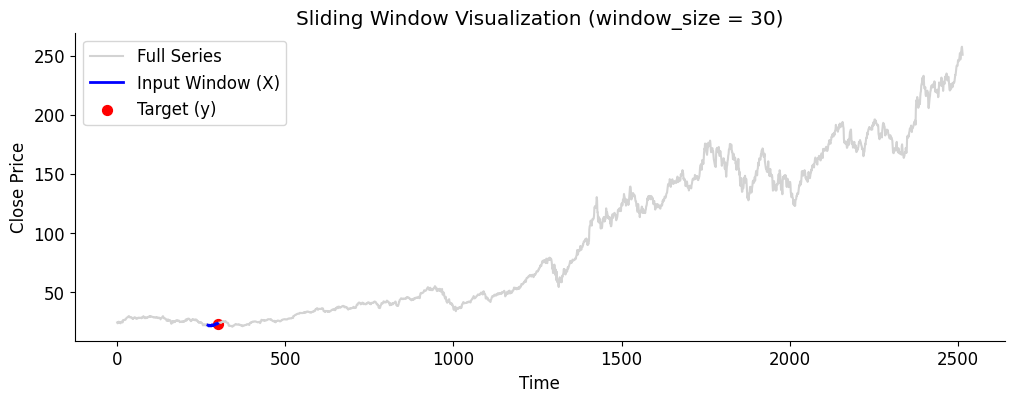

In [17]:
# Sliding window visualization
i = 300
window_size = 30

plt.figure(figsize=(12, 4))

# Full series (light background)
plt.plot(df['Close'].values, color='lightgrey', label='Full Series')

# Sliding window (X)
plt.plot(
    range(i - window_size, i),
    df['Close'].values[i - window_size:i],
    color='blue',
    linewidth=2,
    label='Input Window (X)'
)

# Target value (y)
plt.scatter(
    i,
    df['Close'].values[i],
    color='red',
    s=50,
    label='Target (y)'
)

plt.title("Sliding Window Visualization (window_size = 30)")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [18]:
# Utility Function
def compile_and_train(model, name, epochs=10, batch_size=32):
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    print(f"{name} trained")
    return history

[![1.png](https://i.postimg.cc/wjdC8g03/1.png)](https://postimg.cc/svw65dFR)

In [19]:
# ==========================================
# SIMPLE RNN, LSTM, GRU, STACKED LSTM MODELS
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense

# Hyperparameters
window_size = 30
batch_size = 32
epochs = 30

# ==========================================
# 1. SIMPLE RNN
# ==========================================
simple_rnn = Sequential([
    Input(shape=(window_size, 1)),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(1)
])

simple_rnn.summary()
simple_rnn.save("RNN.h5")

hist_rnn = compile_and_train(
    simple_rnn,
    "Simple RNN",
    epochs=epochs,
    batch_size=batch_size
)







Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0045
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.5110e-04
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3720e-04
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3155e-04
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2937e-04
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2421e-04
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1671e-04
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1217e-04
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0929e-04
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0685e-04
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0487e-04
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0313e-04
Epoch 13/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0061e-04
Epoch 14/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.8699e-05
Epoch 15/30
63/63 ━━━━━━━━━━━━━━━

[![2.png](https://i.postimg.cc/HsCmHwLp/2.png)](https://postimg.cc/V54pWbMT)

In [20]:

# ==========================================
# 2. LSTM
# ==========================================
lstm_model = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.summary()

hist_lstm = compile_and_train(
    lstm_model,
    "LSTM",
    epochs=epochs,
    batch_size=batch_size
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0082
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1659e-04
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.0275e-04
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8782e-04
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.7475e-04
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.6459e-04
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5553e-04
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4939e-04
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4408e-04
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3921e-04
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3486e-04
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.3101e-04
Epoch 13/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.2707e-04
Epoch 14/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.2347e-04
Epoch 15/30
63/63 ━

[![3.png](https://i.postimg.cc/mgH7MGsh/3.png)](https://postimg.cc/SnmXF3jp)

In [21]:
# ==========================================
# 3. GRU
# ==========================================
gru_model = Sequential([
    Input(shape=(window_size, 1)),
    GRU(64),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_model.summary()

hist_gru = compile_and_train(
    gru_model,
    "GRU",
    epochs=epochs,
    batch_size=batch_size
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0084
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0005e-04
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.9136e-05
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.4736e-05
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.1773e-05
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.9433e-05
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.6988e-05
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.5125e-05
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.3529e-05
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.1991e-05
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.0688e-05
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.9933e-05
Epoch 13/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.9275e-05
Epoch 14/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.8826e-05
Epoch 15/30
63/63 ━

[![GRU.png](https://i.postimg.cc/QdD4NPDY/GRU.png)](https://postimg.cc/8jyBtZjL)

[![4.png](https://i.postimg.cc/XXMY6mDm/4.png)](https://postimg.cc/fSKNx2sf)

In [22]:
# ==========================================
# 4. STACKED (DEEP) LSTM
# ==========================================
stacked_lstm = Sequential([
    Input(shape=(window_size, 1)),
    
    LSTM(128, return_sequences=True),
    LSTM(64, return_sequences=True),
    LSTM(32),
    
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

stacked_lstm.summary()
stacked_lstm.save("stackedLSTM.h5")

hist_stacked = compile_and_train(
    stacked_lstm,
    "Stacked LSTM",
    epochs=epochs,
    batch_size=batch_size
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,985 (507.75 KB)

 Trainable params: 129,985 (507.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 0.0068
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 4.3987e-04
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 4.1605e-04
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 4.0934e-04
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 4.0482e-04
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 3.8790e-04
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 3.6740e-04
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 3.3414e-04
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 3.1159e-04
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 2.8860e-04
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 2.6989e-04
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 2.5425e-04
Epoch 13/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 2.4460e-04
Epoch 14/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 2.3580e-04
Epoch 15/30
63/63 

          Model       MSE      RMSE       MAE  R2 Score
0    Simple RNN  0.001833  0.042817  0.029201  0.863599
1          LSTM  0.000313  0.017699  0.013873  0.976694
2           GRU  0.000156  0.012501  0.009581  0.988374
3  Stacked LSTM  0.000810  0.028458  0.023435  0.939744

Best Model Based on RMSE:
Model            GRU
MSE         0.000156
RMSE        0.012501
MAE         0.009581
R2 Score    0.988374
Name: 2, dtype: object


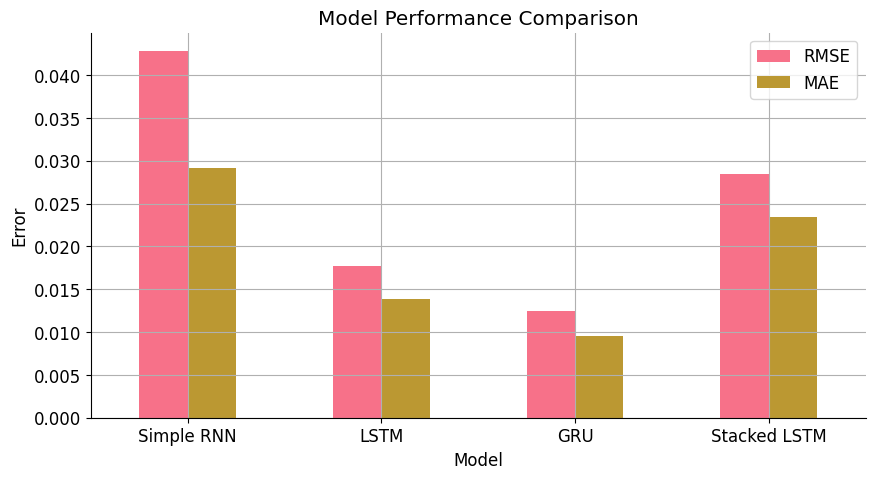

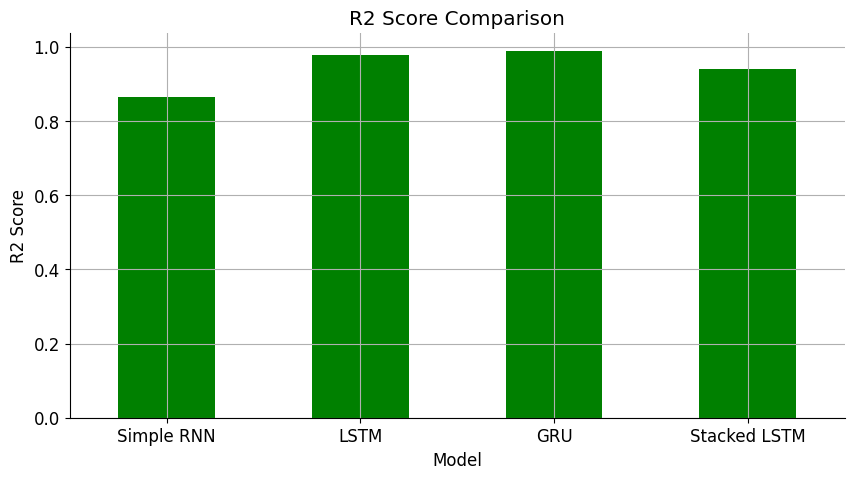

In [23]:
# ==========================================
# COMPARE MODEL PERFORMANCES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ------------------------------------------
# Function to evaluate a trained model
# ------------------------------------------
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test, verbose=0)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    }

# ------------------------------------------
# Evaluate all models
# ------------------------------------------
results = []

results.append(evaluate_model(simple_rnn, X_test, y_test, "Simple RNN"))
results.append(evaluate_model(lstm_model, X_test, y_test, "LSTM"))
results.append(evaluate_model(gru_model, X_test, y_test, "GRU"))
results.append(evaluate_model(stacked_lstm, X_test, y_test, "Stacked LSTM"))

# ------------------------------------------
# Create Comparison Table
# ------------------------------------------
df_results = pd.DataFrame(results)
print(df_results)

# ------------------------------------------
# Best Model
# ------------------------------------------
best_model = df_results.loc[df_results["RMSE"].idxmin()]
print("\nBest Model Based on RMSE:")
print(best_model)

# ==========================================
# BAR CHART COMPARISON
# ==========================================
df_results.set_index("Model")[["RMSE", "MAE"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

# ==========================================
# R2 SCORE COMPARISON
# ==========================================
df_results.set_index("Model")["R2 Score"].plot(
    kind="bar",
    figsize=(10,5),
    color="green"
)

plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

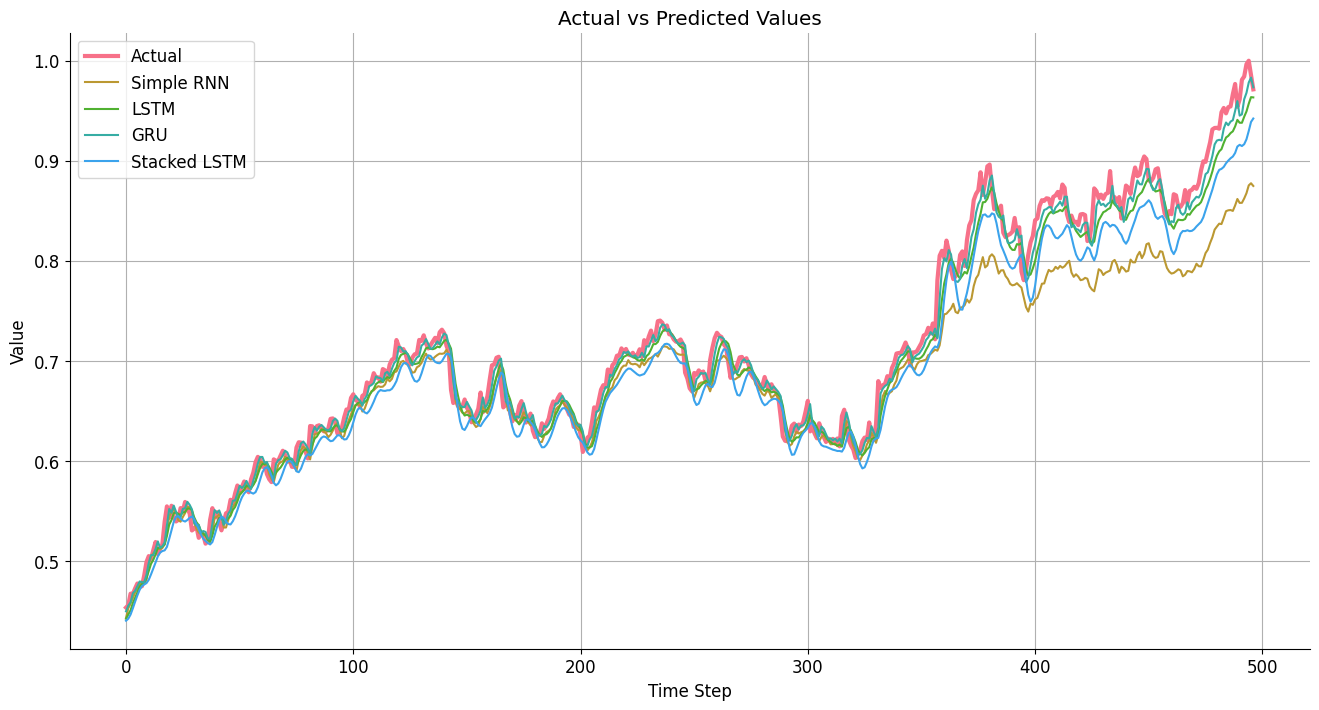

In [24]:
# ==========================================
# ACTUAL vs PREDICTIONS FOR ALL MODELS
# ==========================================

import matplotlib.pyplot as plt

# ------------------------------------------
# Predictions
# ------------------------------------------
y_pred_rnn     = simple_rnn.predict(X_test, verbose=0)
y_pred_lstm    = lstm_model.predict(X_test, verbose=0)
y_pred_gru     = gru_model.predict(X_test, verbose=0)
y_pred_stacked = stacked_lstm.predict(X_test, verbose=0)

# Flatten predictions
y_pred_rnn     = y_pred_rnn.flatten()
y_pred_lstm    = y_pred_lstm.flatten()
y_pred_gru     = y_pred_gru.flatten()
y_pred_stacked = y_pred_stacked.flatten()

y_actual = y_test.flatten()

# ==========================================
# Plot
# ==========================================
plt.figure(figsize=(16,8))

plt.plot(y_actual, label="Actual", linewidth=3)

plt.plot(y_pred_rnn, label="Simple RNN")
plt.plot(y_pred_lstm, label="LSTM")
plt.plot(y_pred_gru, label="GRU")
plt.plot(y_pred_stacked, label="Stacked LSTM")

plt.title("Actual vs Predicted Values")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()